# I. Import and Setups

## I.1. Import Modules

In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os
import pandas as pd

In [191]:
import itertools
from sklearn.metrics import classification_report

In [192]:
from PIL import Image
from tkinter import filedialog
from tkinter import Tk

## sadasds

In [62]:
IMAGE_SIZE = 256
CHANNELS = 3
BATCH_SIZE_32 = 32
BATCH_SIZE_16 = 16
BATCH_SIZE_48 = 48
EPOCH_30 = 30
EPOCH_50 = 50
N_CLASS = 3

# II. Importing Data and Exploring Data

## II.1. Importing Data

In [4]:
dataset_16 = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    seed = 123,
    shuffle = True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE_16
)

Found 4062 files belonging to 3 classes.


In [5]:
dataset_32 = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    seed = 123,
    shuffle = True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE_32
)

Found 4062 files belonging to 3 classes.


In [6]:
dataset_48 = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    seed = 123,
    shuffle = True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE_48
)

Found 4062 files belonging to 3 classes.


## II.2. Exploring Data

In [7]:
class_names_16 = dataset_16.class_names
class_names_16

['Early_Blight', 'Healthy', 'Late_Blight']

In [8]:
class_names_32 = dataset_32.class_names
class_names_32

['Early_Blight', 'Healthy', 'Late_Blight']

In [9]:
class_names_48 = dataset_48.class_names
class_names_48

['Early_Blight', 'Healthy', 'Late_Blight']

In [10]:
diseases_dir = "dataset"
diseases = os.listdir(diseases_dir)

In [11]:
nums = {}
for disease in diseases:
    nums[disease] = len(os.listdir(diseases_dir + '/' + disease))
    
# converting the nums dictionary to pandas dataframe passing index as plant name and number of images as column
img_per_class_df = pd.DataFrame(nums.values(), index=nums.keys(), columns=["No. of images"])

In [12]:
img_per_class_df.sample(N_CLASS).style.set_properties(**{'background-color': '#f9f9f9', 'color': '#4CAF50', 'font-weight': 'bold'})

,No. of images
Healthy,1020
Early_Blight,1628
Late_Blight,1414


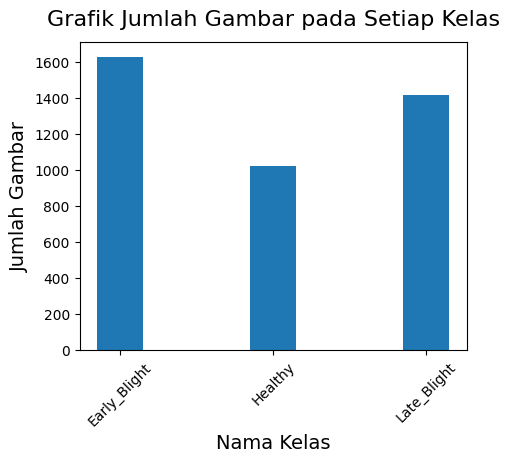

In [13]:
#plotting number of images available for each class
index = [n for n in range(N_CLASS)]
plt.figure(figsize=(5, 4))
plt.bar(index, [n for n in nums.values()], width=0.3)
plt.xlabel('Nama Kelas', fontsize=14)
plt.ylabel('Jumlah Gambar', fontsize=14)
plt.xticks(index, diseases, fontsize=10, rotation=45)
plt.title('Grafik Jumlah Gambar pada Setiap Kelas', fontsize=16, pad=12)
plt.show()

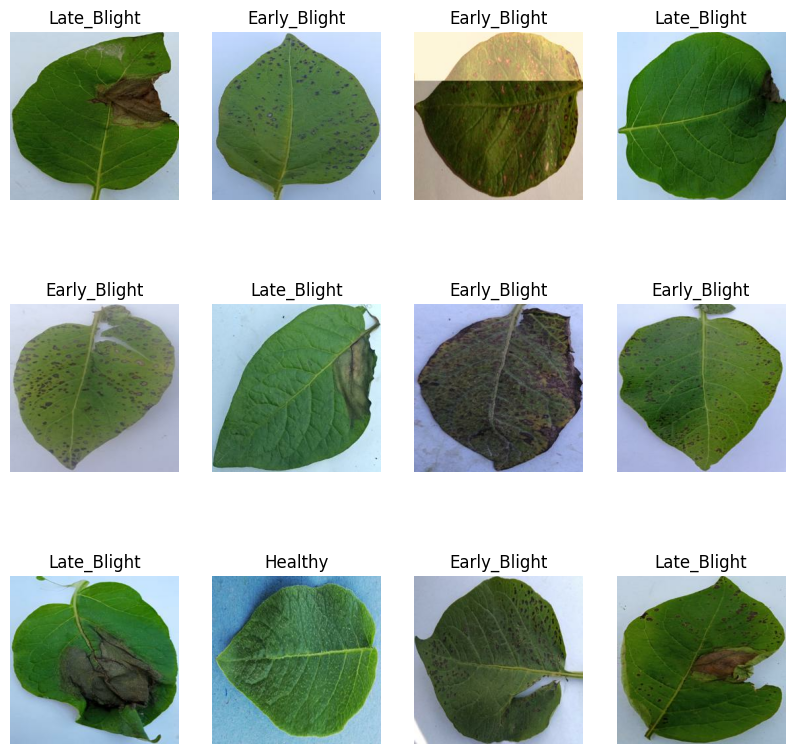

In [14]:
fig = plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset_16.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names_16[labels_batch[i]])
        plt.axis("off")
fig.savefig('category_samples.png', dpi=300)

# III. Data Preparation

## III.1. Train-Val-Test Data Split

### a. for batch 16

In [15]:
len(dataset_16)

254

In [16]:
def get_dataset_partitions_tf_16(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds_16 = ds.take(train_size)    
    val_ds_16 = ds.skip(train_size).take(val_size)
    test_ds_16 = ds.skip(train_size).skip(val_size)
    
    return train_ds_16, val_ds_16, test_ds_16

In [17]:
train_ds_16, val_ds_16, test_ds_16 = get_dataset_partitions_tf_16(dataset_16)

In [18]:
len(train_ds_16)

203

In [19]:
len(val_ds_16)

25

In [20]:
len(test_ds_16)

26

### b. for batch 32

In [21]:
len(dataset_32)

127

In [22]:
def get_dataset_partitions_tf_32(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds_32 = ds.take(train_size)    
    val_ds_32 = ds.skip(train_size).take(val_size)
    test_ds_32 = ds.skip(train_size).skip(val_size)
    
    return train_ds_32, val_ds_32, test_ds_32

In [23]:
train_ds_32, val_ds_32, test_ds_32 = get_dataset_partitions_tf_32(dataset_32)

In [24]:
len(train_ds_32)

101

In [25]:
len(val_ds_32)

12

In [26]:
len(test_ds_32)

14

### c. for batch 48

In [27]:
len(dataset_48)

85

In [28]:
def get_dataset_partitions_tf_48(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds_48 = ds.take(train_size)    
    val_ds_48 = ds.skip(train_size).take(val_size)
    test_ds_48 = ds.skip(train_size).skip(val_size)
    
    return train_ds_48, val_ds_48, test_ds_48

In [29]:
train_ds_48, val_ds_48, test_ds_48 = get_dataset_partitions_tf_48(dataset_48)

In [30]:
len(train_ds_48)

68

In [31]:
len(val_ds_48)

8

In [32]:
len(test_ds_48)

9

## III.2. Optimize Tensorflow Pipeline Performance

### a. for batch 16

In [33]:
train_ds_16 = train_ds_16.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds_16 = val_ds_16.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds_16 = test_ds_16.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

### b. for batch 32

In [34]:
train_ds_32 = train_ds_32.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds_32 = val_ds_32.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds_32 = test_ds_32.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

### c. for batch 48

In [35]:
train_ds_48 = train_ds_48.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds_48 = val_ds_48.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds_48 = test_ds_48.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

## III.3. Resize and Rescale 

In [36]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

## III.4. Data Augmentation

### III.4.1. Initialize data augmentation method

In [37]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

### III.4.2. Applying Data Augmentation to Train Dataset

#### a. for batch 16

In [38]:
train_ds_16 = train_ds_16.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

#### b. for batch 32

In [39]:
train_ds_32 = train_ds_32.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

#### c. for batch 48

In [40]:
train_ds_48 = train_ds_48.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

# IV. Model Creation

## IV.1. Model Creation Tahap I

**Fokus pada tuning optimizer, epoch, dan jumlah conv layer. Batch size pada Model Creation Tahap I ini tetap pada 32**

### IV.1.1. Model A

**Optimizer Adam, epoch 30, jumlah conv layer 4, batch size 32**

In [43]:
input_shape = (BATCH_SIZE_32, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model_cnn_a = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(N_CLASS, activation='softmax'),
])

model_cnn_a.build(input_shape=input_shape)

In [44]:
model_cnn_a.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 12544)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,323 (3.42 MB)

 Trainable params: 896,323 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model_cnn_a.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [46]:
history = model_cnn_a.fit(
    train_ds_32,
    batch_size = BATCH_SIZE_32,
    validation_data = val_ds_32,
    epochs = EPOCH_30,
    verbose = 1
)

Epoch 1/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.4209 - loss: 1.0527 - val_accuracy: 0.5859 - val_loss: 0.9221
Epoch 2/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.5181 - loss: 0.9733 - val_accuracy: 0.5078 - val_loss: 0.9167
Epoch 3/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.5459 - loss: 0.9040 - val_accuracy: 0.6615 - val_loss: 0.8052
Epoch 4/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.6827 - loss: 0.7629 - val_accuracy: 0.7240 - val_loss: 0.7230
Epoch 5/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.7397 - loss: 0.6647 - val_accuracy: 0.7839 - val_loss: 0.5759
Epoch 6/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.7459 - loss: 0.6413 - val_accuracy: 0.7552 - val_loss: 0.5361
Epoch 7/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.7829 - loss: 0.5615 - val_accuracy: 0.7708 - val_loss: 0.5644
Epoch 8/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.7844 - loss: 0.5219 - val_accu

### IV.1.2. Model B

**Optimizer Adam, epoch 30, jumlah conv layer 6, batch size 32**

In [48]:
input_shape_b = (BATCH_SIZE_32, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model_cnn_b = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape_b),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(N_CLASS, activation='softmax'),
])

model_cnn_b.build(input_shape=input_shape_b)

In [50]:
model_cnn_b.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model_cnn_b.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [52]:
history_b = model_cnn_b.fit(
    train_ds_32,
    batch_size = BATCH_SIZE_32,
    validation_data = val_ds_32,
    epochs = EPOCH_30,
    verbose = 1
)

Epoch 1/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.4053 - loss: 1.0600 - val_accuracy: 0.6302 - val_loss: 0.8701
Epoch 2/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.5846 - loss: 0.8890 - val_accuracy: 0.6406 - val_loss: 0.7742
Epoch 3/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.6942 - loss: 0.7205 - val_accuracy: 0.8021 - val_loss: 0.5139
Epoch 4/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.8271 - loss: 0.4587 - val_accuracy: 0.8724 - val_loss: 0.3101
Epoch 5/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8858 - loss: 0.3238 - val_accuracy: 0.9271 - val_loss: 0.1927
Epoch 6/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9088 - loss: 0.2361 - val_accuracy: 0.9141 - val_loss: 0.2039
Epoch 7/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9177 - loss: 0.2295 - val_accuracy: 0.9479 - val_loss: 0.1443
Epoch 8/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9296 - loss: 0.1858 - val_accu

### IV.1.3. Model c

**Optimizer Adam, epoch 30, jumlah conv layer 8, batch size 32**

In [55]:
input_shape_c = (BATCH_SIZE_32, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model_cnn_c = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape_c),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(N_CLASS, activation='softmax'),
])

model_cnn_c.build(input_shape=input_shape_c)

In [60]:
model_cnn_c.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (32, 58, 58, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (32, 29, 29, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (32, 27, 27, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (32, 13, 13, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (32, 11, 11, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (32, 9, 9, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (32, 7, 7, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (32, 3, 3, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (32, 576)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (32, 64)               │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 834,251 (3.18 MB)

 Trainable params: 278,083 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 556,168 (2.12 MB)

In [56]:
model_cnn_c.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [57]:
history_c = model_cnn_c.fit(
    train_ds_32,
    batch_size = BATCH_SIZE_32,
    validation_data = val_ds_32,
    epochs = EPOCH_30,
    verbose = 1
)

Epoch 1/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.3964 - loss: 1.0725 - val_accuracy: 0.5651 - val_loss: 0.9611
Epoch 2/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.5691 - loss: 0.9423 - val_accuracy: 0.6719 - val_loss: 0.7602
Epoch 3/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.7231 - loss: 0.6951 - val_accuracy: 0.7578 - val_loss: 0.5138
Epoch 4/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.7841 - loss: 0.5473 - val_accuracy: 0.8177 - val_loss: 0.4353
Epoch 5/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.8128 - loss: 0.5370 - val_accuracy: 0.7682 - val_loss: 0.5076
Epoch 6/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.8500 - loss: 0.3899 - val_accuracy: 0.8672 - val_loss: 0.3638
Epoch 7/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.8726 - loss: 0.3321 - val_accuracy: 0.8828 - val_loss: 0.3018
Epoch 8/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.8996 - loss: 0.2414 - val_accu

### IV.1.4. Model d

**Optimizer Adam, epoch 50, jumlah conv layer 4, batch size 32**

In [74]:
input_shape_d_4 = (BATCH_SIZE_32, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model_cnn_d_4 = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape_d_4),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(N_CLASS, activation='softmax'),
])

model_cnn_d_4.build(input_shape=input_shape_d_4)

In [75]:
model_cnn_d_4.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (32, 12544)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (32, 64)               │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,323 (3.42 MB)

 Trainable params: 896,323 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [76]:
model_cnn_d_4.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [77]:
history_d_4 = model_cnn_d_4.fit(
    train_ds_32,
    batch_size = BATCH_SIZE_32,
    validation_data = val_ds_32,
    epochs = EPOCH_50,
    verbose = 1 
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.4734 - loss: 1.0246 - val_accuracy: 0.5651 - val_loss: 0.9372
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7095 - loss: 0.7236 - val_accuracy: 0.8151 - val_loss: 0.4836
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8093 - loss: 0.5079 - val_accuracy: 0.8672 - val_loss: 0.3315
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8659 - loss: 0.3796 - val_accuracy: 0.8776 - val_loss: 0.3176
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.8859 - loss: 0.2982 - val_accuracy: 0.9115 - val_loss: 0.2167
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9144 - loss: 0.2373 - val_accuracy: 0.9297 - val_loss: 0.2070
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9320 - loss: 0.1864 - val_accuracy: 0.8958 - val_loss: 0.2564
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9077 - loss: 0.2665 - val_accu

### IV.1.5. Model e

**Optimizer Adam, epoch 50, jumlah conv layer 6, batch size 32**

In [79]:
input_shape_e = (BATCH_SIZE_32, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model_cnn_e = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape_e),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(N_CLASS, activation='softmax'),
])

model_cnn_e.build(input_shape=input_shape_e)

In [330]:
model_cnn_e.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,243 (2.10 MB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 367,496 (1.40 MB)

In [81]:
model_cnn_e.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [82]:
history_e = model_cnn_e.fit(
    train_ds_32,
    batch_size = BATCH_SIZE_32,
    validation_data = val_ds_32,
    epochs = EPOCH_50,
    verbose = 1
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.4397 - loss: 1.0560 - val_accuracy: 0.5833 - val_loss: 0.9511
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.5963 - loss: 0.8955 - val_accuracy: 0.7005 - val_loss: 0.7045
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.7249 - loss: 0.7056 - val_accuracy: 0.8333 - val_loss: 0.4764
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8306 - loss: 0.4555 - val_accuracy: 0.8958 - val_loss: 0.3054
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.8824 - loss: 0.3184 - val_accuracy: 0.9036 - val_loss: 0.3371
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8977 - loss: 0.2972 - val_accuracy: 0.8490 - val_loss: 0.6127
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9107 - loss: 0.2533 - val_accuracy: 0.8958 - val_loss: 0.2572
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9390 - loss: 0.1770 - val_accu

### IV.1.6. Model f

**Optimizer Adam, epoch 50, jumlah conv layer 8, batch size 32**

In [84]:
input_shape_f = (BATCH_SIZE_32, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model_cnn_f = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape_f),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(N_CLASS, activation='softmax'),
])

model_cnn_f.build(input_shape=input_shape_f)

In [85]:
model_cnn_f.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [86]:
history_f = model_cnn_f.fit(
    train_ds_32,
    batch_size = BATCH_SIZE_32,
    validation_data = val_ds_32,
    epochs = EPOCH_50,
    verbose = 1
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.4275 - loss: 1.0723 - val_accuracy: 0.5234 - val_loss: 0.9814
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.5188 - loss: 0.9887 - val_accuracy: 0.4505 - val_loss: 0.9671
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.5117 - loss: 0.9784 - val_accuracy: 0.6250 - val_loss: 0.8815
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.5660 - loss: 0.9359 - val_accuracy: 0.6198 - val_loss: 0.8535
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.5910 - loss: 0.8914 - val_accuracy: 0.7083 - val_loss: 0.7389
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.7171 - loss: 0.7227 - val_accuracy: 0.7917 - val_loss: 0.5663
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.7441 - loss: 0.6153 - val_accuracy: 0.8255 - val_loss: 0.4820
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.8209 - loss: 0.4879 - val_accu

### IV.1.7. Model g

**Optimizer RMSProp, epoch 30, jumlah conv layer 4, batch size 32**

In [87]:
input_shape_g = (BATCH_SIZE_32, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model_cnn_g = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape_g),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(N_CLASS, activation='softmax'),
])

model_cnn_g.build(input_shape=input_shape_g)

In [88]:
model_cnn_g.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (32, 12544)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (32, 64)               │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,323 (3.42 MB)

 Trainable params: 896,323 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [89]:
model_cnn_g.compile(
    optimizer = 'rmsprop',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [90]:
history_g = model_cnn_g.fit(
    train_ds_32,
    batch_size = BATCH_SIZE_32,
    validation_data = val_ds_32,
    epochs = EPOCH_30,
    verbose = 1
)

Epoch 1/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.4018 - loss: 1.0797 - val_accuracy: 0.5964 - val_loss: 0.8974
Epoch 2/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.6189 - loss: 0.8923 - val_accuracy: 0.6276 - val_loss: 0.8122
Epoch 3/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.7282 - loss: 0.7033 - val_accuracy: 0.8177 - val_loss: 0.5075
Epoch 4/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.7635 - loss: 0.6123 - val_accuracy: 0.8073 - val_loss: 0.4545
Epoch 5/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.8094 - loss: 0.5435 - val_accuracy: 0.7786 - val_loss: 0.5182
Epoch 6/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.8536 - loss: 0.4178 - val_accuracy: 0.7526 - val_loss: 0.6232
Epoch 7/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.8560 - loss: 0.4072 - val_accuracy: 0.8568 - val_loss: 0.4094
Epoch 8/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8998 - loss: 0.2990 - val_accu

### IV.1.8. Model h

**Optimizer RMSProp, epoch 30, jumlah conv layer 6, batch size 32**

In [95]:
input_shape_h_2 = (BATCH_SIZE_32, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model_cnn_h_2 = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape_h_2),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(N_CLASS, activation='softmax'),
])

model_cnn_h_2.build(input_shape=input_shape_h_2)

In [96]:
model_cnn_h_2.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_59 (MaxPooling2D) │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_60 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_61 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_62 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
model_cnn_h_2.compile(
    optimizer = 'rmsprop',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [98]:
history_h_2 = model_cnn_h_2.fit(
    train_ds_32,
    batch_size = BATCH_SIZE_32,
    validation_data = val_ds_32,
    epochs = EPOCH_30,
    verbose = 1
)

Epoch 1/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.4049 - loss: 1.0859 - val_accuracy: 0.5547 - val_loss: 0.9334
Epoch 2/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.5511 - loss: 0.9543 - val_accuracy: 0.7266 - val_loss: 0.7195
Epoch 3/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.7073 - loss: 0.7420 - val_accuracy: 0.7604 - val_loss: 0.6157
Epoch 4/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.7642 - loss: 0.6001 - val_accuracy: 0.8151 - val_loss: 0.4251
Epoch 5/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.8247 - loss: 0.4585 - val_accuracy: 0.8281 - val_loss: 0.3928
Epoch 6/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8508 - loss: 0.3998 - val_accuracy: 0.8880 - val_loss: 0.4088
Epoch 7/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8938 - loss: 0.2983 - val_accuracy: 0.9115 - val_loss: 0.2382
Epoch 8/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9016 - loss: 0.2555 - val_accu

### IV.1.9. Model i

**Optimizer RMSProp, epoch 30, jumlah conv layer 8, batch size 32**

In [99]:
input_shape_i = (BATCH_SIZE_32, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model_cnn_i = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape_i),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(N_CLASS, activation='softmax'),
])

model_cnn_i.build(input_shape=input_shape_i)

In [100]:
model_cnn_i.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (32, 58, 58, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (32, 29, 29, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (32, 27, 27, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_66 (MaxPooling2D) │ (32, 13, 13, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (32, 11, 11, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (32, 9, 9, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (32, 7, 7, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_67 (MaxPooling2D) │ (32, 3, 3, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (32, 576)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (32, 64)               │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,083 (1.06 MB)

 Trainable params: 278,083 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [101]:
model_cnn_i.compile(
    optimizer = 'rmsprop',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [102]:
history_i = model_cnn_i.fit(
    train_ds_32,
    batch_size = BATCH_SIZE_32,
    validation_data = val_ds_32,
    epochs = EPOCH_30,
    verbose = 1
)

Epoch 1/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.3856 - loss: 1.0933 - val_accuracy: 0.3984 - val_loss: 1.0692
Epoch 2/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.4646 - loss: 1.0458 - val_accuracy: 0.4974 - val_loss: 0.9749
Epoch 3/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.6364 - loss: 0.8645 - val_accuracy: 0.7031 - val_loss: 0.6997
Epoch 4/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.6824 - loss: 0.7657 - val_accuracy: 0.7708 - val_loss: 0.5768
Epoch 5/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.7409 - loss: 0.6163 - val_accuracy: 0.8229 - val_loss: 0.4407
Epoch 6/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.8059 - loss: 0.5031 - val_accuracy: 0.8177 - val_loss: 0.4878
Epoch 7/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.8235 - loss: 0.4573 - val_accuracy: 0.9010 - val_loss: 0.2908
Epoch 8/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.8580 - loss: 0.4123 - val_accu

### IV.1.10. Model j

**Optimizer RMSProp, epoch 50, jumlah conv layer 4, batch size 32**

In [103]:
input_shape_j = (BATCH_SIZE_32, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model_cnn_j = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape_j),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(N_CLASS, activation='softmax'),
])

model_cnn_j.build(input_shape=input_shape_j)

In [105]:
model_cnn_j.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_68 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_70 (MaxPooling2D) │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_71 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (32, 12544)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (32, 64)               │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,323 (3.42 MB)

 Trainable params: 896,323 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [106]:
model_cnn_j.compile(
    optimizer = 'rmsprop',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [107]:
history_j = model_cnn_j.fit(
    train_ds_32,
    batch_size = BATCH_SIZE_32,
    validation_data = val_ds_32,
    epochs = EPOCH_50,
    verbose = 1 
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.4057 - loss: 1.0936 - val_accuracy: 0.5026 - val_loss: 0.9778
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.5575 - loss: 0.9417 - val_accuracy: 0.6094 - val_loss: 0.8905
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.6615 - loss: 0.7757 - val_accuracy: 0.7682 - val_loss: 0.5580
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.7554 - loss: 0.6376 - val_accuracy: 0.8672 - val_loss: 0.4024
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8151 - loss: 0.5039 - val_accuracy: 0.8516 - val_loss: 0.3571
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8563 - loss: 0.3963 - val_accuracy: 0.8177 - val_loss: 0.5177
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8432 - loss: 0.4013 - val_accuracy: 0.8542 - val_loss: 0.3461
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8826 - loss: 0.3212 - val_accu

### IV.1.11. Model k

**Optimizer RMSProp, epoch 50, jumlah conv layer 6, batch size 32**

In [110]:
input_shape_k = (BATCH_SIZE_32, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model_cnn_k = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape_k),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(N_CLASS, activation='softmax'),
])

model_cnn_k.build(input_shape=input_shape_k)

In [329]:
model_cnn_k.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_78 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_79 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_92 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_80 (MaxPooling2D) │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_81 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_82 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_83 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 367,496 (1.40 MB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 183,749 (717.77 KB)

In [112]:
model_cnn_k.compile(
    optimizer = 'rmsprop',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [113]:
history_k = model_cnn_k.fit(
    train_ds_32,
    batch_size = BATCH_SIZE_32,
    validation_data = val_ds_32,
    epochs = EPOCH_50,
    verbose = 1
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.4045 - loss: 1.0990 - val_accuracy: 0.5885 - val_loss: 0.9799
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.5607 - loss: 0.9604 - val_accuracy: 0.6328 - val_loss: 0.8202
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6641 - loss: 0.7989 - val_accuracy: 0.7031 - val_loss: 0.7131
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.7595 - loss: 0.6351 - val_accuracy: 0.8620 - val_loss: 0.4174
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.8309 - loss: 0.4477 - val_accuracy: 0.6849 - val_loss: 0.7418
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.8502 - loss: 0.3884 - val_accuracy: 0.8542 - val_loss: 0.4256
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.8655 - loss: 0.3407 - val_accuracy: 0.9141 - val_loss: 0.2206
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.8819 - loss: 0.3163 - val_accu

### IV.1.12. Model l

**Optimizer RMSProp, epoch 50, jumlah conv layer 8, batch size 32**

In [114]:
input_shape_l_2 = (BATCH_SIZE_32, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model_cnn_l_2 = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape_l_2),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(N_CLASS, activation='softmax'),
])

model_cnn_l_2.build(input_shape=input_shape_l_2)

In [115]:
model_cnn_l_2.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_84 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_85 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ (32, 58, 58, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_86 (MaxPooling2D) │ (32, 29, 29, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_100 (Conv2D)             │ (32, 27, 27, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_87 (MaxPooling2D) │ (32, 13, 13, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_101 (Conv2D)             │ (32, 11, 11, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_102 (Conv2D)             │ (32, 9, 9, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_103 (Conv2D)             │ (32, 7, 7, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_88 (MaxPooling2D) │ (32, 3, 3, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (32, 576)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (32, 64)               │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,083 (1.06 MB)

 Trainable params: 278,083 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [116]:
model_cnn_l_2.compile(
    optimizer = 'rmsprop',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [117]:
history_l_2 = model_cnn_l_2.fit(
    train_ds_32,
    batch_size = BATCH_SIZE_32,
    validation_data = val_ds_32,
    epochs = EPOCH_50,
    verbose = 1
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.4068 - loss: 1.0958 - val_accuracy: 0.4505 - val_loss: 1.0250
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.4625 - loss: 1.0271 - val_accuracy: 0.5729 - val_loss: 0.9109
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.6109 - loss: 0.9071 - val_accuracy: 0.6510 - val_loss: 0.8439
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.6480 - loss: 0.7564 - val_accuracy: 0.6823 - val_loss: 0.6671
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.7488 - loss: 0.6042 - val_accuracy: 0.8359 - val_loss: 0.4034
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.8181 - loss: 0.4940 - val_accuracy: 0.8438 - val_loss: 0.4600
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.8353 - loss: 0.4948 - val_accuracy: 0.9036 - val_loss: 0.2553
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.8595 - loss: 0.3637 - val_accu

## IV.2. Model Evaluation pada Model Hasil dari Model Creation I

### IV.2.1. Model A

**Optimizer Adam, epoch 30, jumlah conv layer 4, batch size 32**

#### a. Training-Validation Accuracy and Loss

In [118]:
history

In [119]:
history.params

{'verbose': 1, 'epochs': 30, 'steps': 101}

In [120]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [123]:
for i in range(-1, 0):  # Last epoch
    print(f"Epoch {i+len(history.history['loss'])+1}:")
    print(f"  training accuracy: {history.history['accuracy'][i]:.4f}")
    print(f"  training loss: {history.history['loss'][i]:.4f}")
    print(f"  val_accuracy: {history.history['val_accuracy'][i]:.4f}")
    print(f"  val_loss: {history.history['val_loss'][i]:.4f}")
    print()

Epoch 30:
  training accuracy: 0.9588
  training loss: 0.1146
  val_accuracy: 0.9740
  val_loss: 0.0970



In [128]:
acc_model_a = history.history['accuracy']
val_acc_model_a = history.history['val_accuracy']

loss_model_a = history.history['loss']
val_loss_model_a = history.history['val_loss']

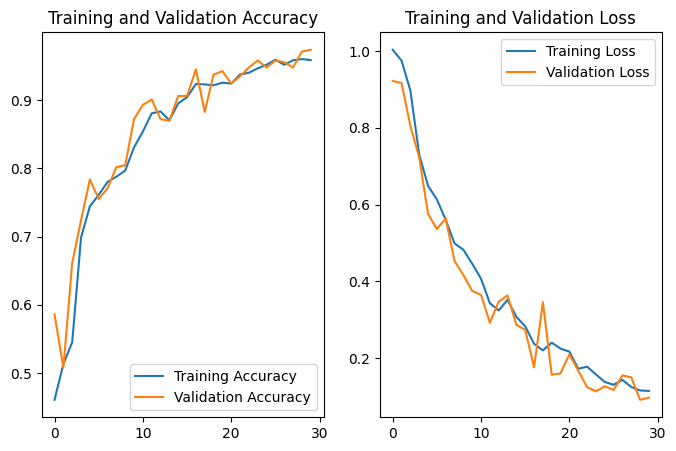

In [132]:
fig_trainVal_acc_a = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCH_30), acc_model_a, label='Training Accuracy')
plt.plot(range(EPOCH_30), val_acc_model_a, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH_30), loss_model_a, label='Training Loss')
plt.plot(range(EPOCH_30), val_loss_model_a, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
fig_trainVal_acc_a.savefig('train_val_acc_a.png', dpi=300)

#### b. Confusion Matrix

In [138]:
y_pred_model_a = []
y_true_model_a = []

# Loop through the test dataset to get true labels and predicted labels
for images, labels in test_ds_32:
    preds_model_a = model_cnn_a.predict(images)
    y_pred_model_a.extend(np.argmax(preds_model_a, axis=1))  # Get the index of the class with the highest probability
    y_true_model_a.extend(labels.numpy())  # Get the true labels

y_pred_model_a = np.array(y_pred_model_a)
y_true_model_a = np.array(y_true_model_a)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step


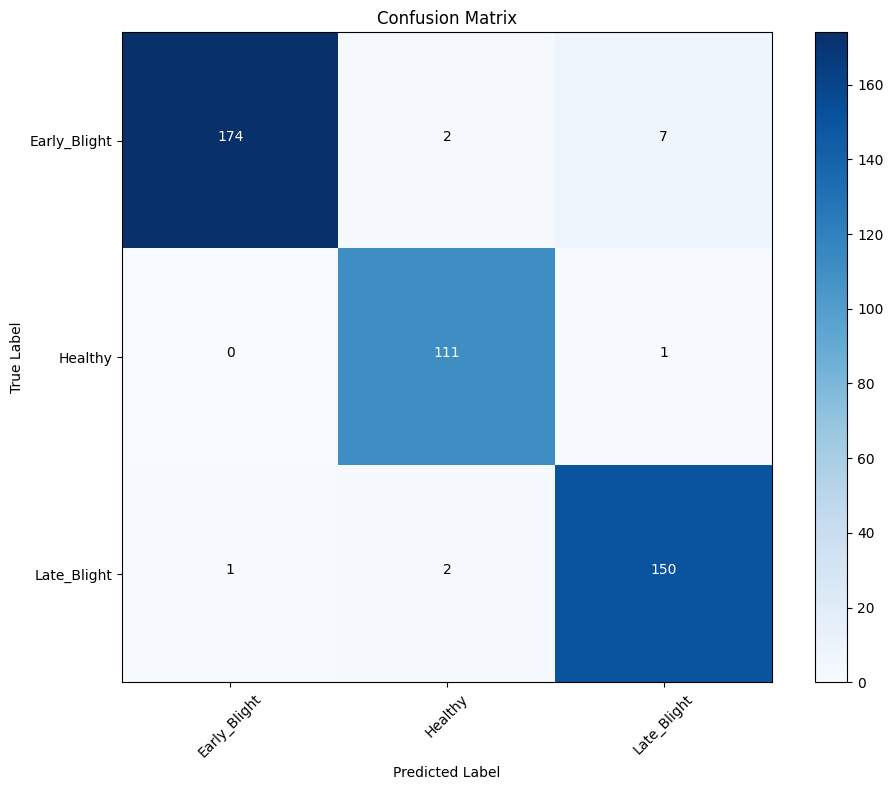

In [152]:
cm = confusion_matrix(y_true_model_a, y_pred_model_a)

def plot_confusion_matrix_model_a(cm, classes):
    fig_cm_a = plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Normalize the confusion matrix by rows (true labels)
    # cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fig_cm_a.savefig('cm_a.png', dpi=300)

plot_confusion_matrix_model_a(cm, class_names_32)
plt.show()

#### c. Precision, Recall, dan F1-Score

In [147]:
print(classification_report(y_true_model_a, y_pred_model_a, target_names=class_names_32))

              precision    recall  f1-score   support

Early_Blight       0.99      0.95      0.97       183
     Healthy       0.97      0.99      0.98       112
 Late_Blight       0.95      0.98      0.96       153

    accuracy                           0.97       448
   macro avg       0.97      0.97      0.97       448
weighted avg       0.97      0.97      0.97       448



### IV.2.2. Model B

**Optimizer Adam, epoch 30, jumlah conv layer 6, batch size 32**

#### a. Training-Validation Accuracy and Loss

In [195]:
history_b

In [196]:
history_b.params

{'verbose': 1, 'epochs': 30, 'steps': 101}

In [198]:
for i in range(-1, 0):  # Last epoch
    print(f"Epoch {i+len(history_b.history['loss'])+1}:")
    print(f"  training accuracy: {history_b.history['accuracy'][i]:.4f}")
    print(f"  training loss: {history_b.history['loss'][i]:.4f}")
    print(f"  val_accuracy: {history_b.history['val_accuracy'][i]:.4f}")
    print(f"  val_loss: {history_b.history['val_loss'][i]:.4f}")
    print()

Epoch 30:
  training accuracy: 0.9796
  training loss: 0.0572
  val_accuracy: 0.9661
  val_loss: 0.0877



In [199]:
acc_model_b = history_b.history['accuracy']
val_acc_model_b = history_b.history['val_accuracy']

loss_model_b = history_b.history['loss']
val_loss_model_b = history_b.history['val_loss']

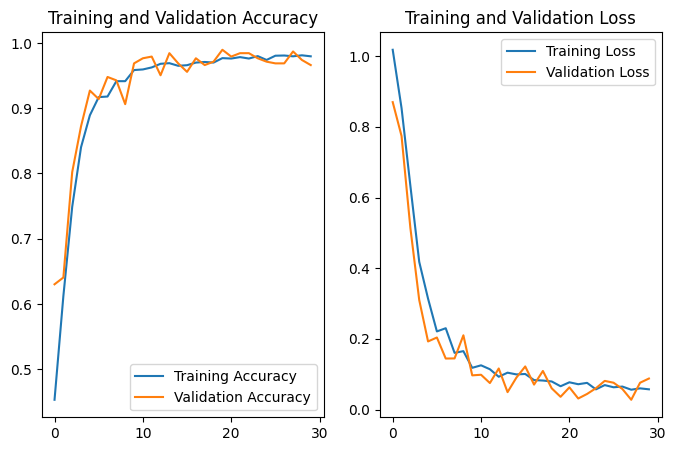

In [200]:
fig_trainVal_acc_b = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCH_30), acc_model_b, label='Training Accuracy')
plt.plot(range(EPOCH_30), val_acc_model_b, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH_30), loss_model_b, label='Training Loss')
plt.plot(range(EPOCH_30), val_loss_model_b, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
fig_trainVal_acc_b.savefig('train_val_acc_b.png', dpi=300)

#### b. Confusion Matrix

In [201]:
y_pred_model_b = []
y_true_model_b = []

# Loop through the test dataset to get true labels and predicted labels
for images, labels in test_ds_32:
    preds_model_b = model_cnn_b.predict(images)
    y_pred_model_b.extend(np.argmax(preds_model_b, axis=1))  # Get the index of the class with the highest probability
    y_true_model_b.extend(labels.numpy())  # Get the true labels

y_pred_model_b = np.array(y_pred_model_b)
y_true_model_b = np.array(y_true_model_b)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


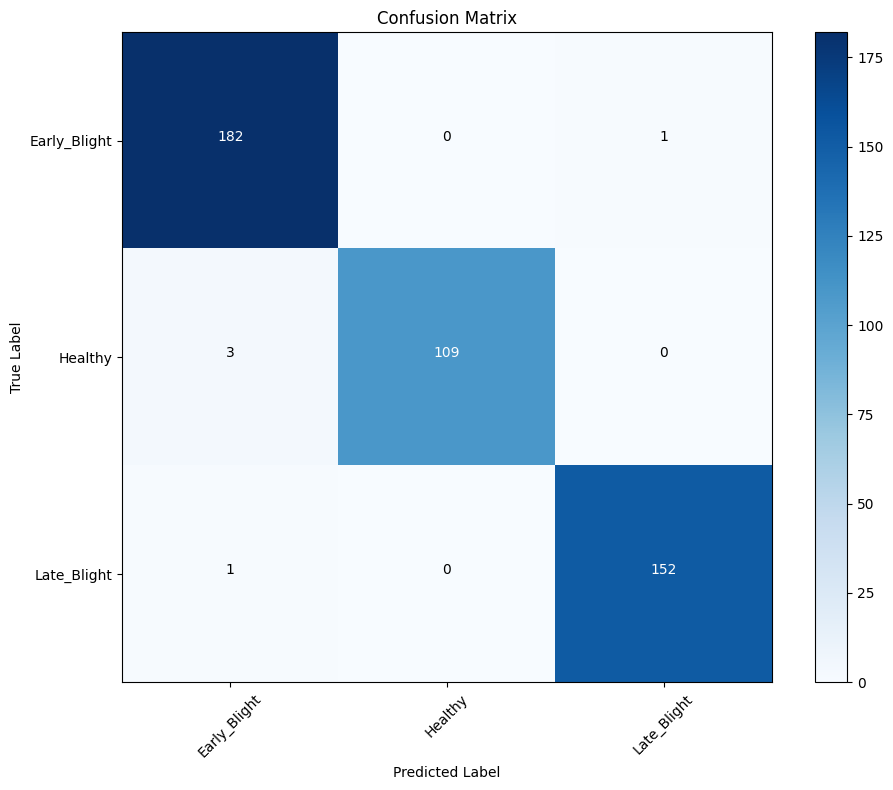

In [203]:
cm = confusion_matrix(y_true_model_b, y_pred_model_b)

def plot_confusion_matrix_model_b(cm, classes):
    fig_cm_b = plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Normalize the confusion matrix by rows (true labels)
    # cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fig_cm_b.savefig('cm_b.png', dpi=300)

plot_confusion_matrix_model_b(cm, class_names_32)
plt.show()

#### c. Precision, Recall, dan F1-Score

In [205]:
print(classification_report(y_true_model_b, y_pred_model_b, target_names=class_names_32))

              precision    recall  f1-score   support

Early_Blight       0.98      0.99      0.99       183
     Healthy       1.00      0.97      0.99       112
 Late_Blight       0.99      0.99      0.99       153

    accuracy                           0.99       448
   macro avg       0.99      0.99      0.99       448
weighted avg       0.99      0.99      0.99       448



### IV.2.3. Model C

**Optimizer Adam, epoch 30, jumlah conv layer 8, batch size 32**

#### a. Training-Validation Accuracy and Loss

In [206]:
history_c

In [207]:
history_c.params

{'verbose': 1, 'epochs': 30, 'steps': 101}

In [208]:
for i in range(-1, 0):  # Last epoch
    print(f"Epoch {i+len(history_c.history['loss'])+1}:")
    print(f"  training accuracy: {history_c.history['accuracy'][i]:.4f}")
    print(f"  training loss: {history_c.history['loss'][i]:.4f}")
    print(f"  val_accuracy: {history_c.history['val_accuracy'][i]:.4f}")
    print(f"  val_loss: {history_c.history['val_loss'][i]:.4f}")
    print()

Epoch 30:
  training accuracy: 0.9737
  training loss: 0.0979
  val_accuracy: 0.9740
  val_loss: 0.0656



In [209]:
acc_model_c = history_c.history['accuracy']
val_acc_model_c = history_c.history['val_accuracy']

loss_model_c = history_c.history['loss']
val_loss_model_c = history_c.history['val_loss']

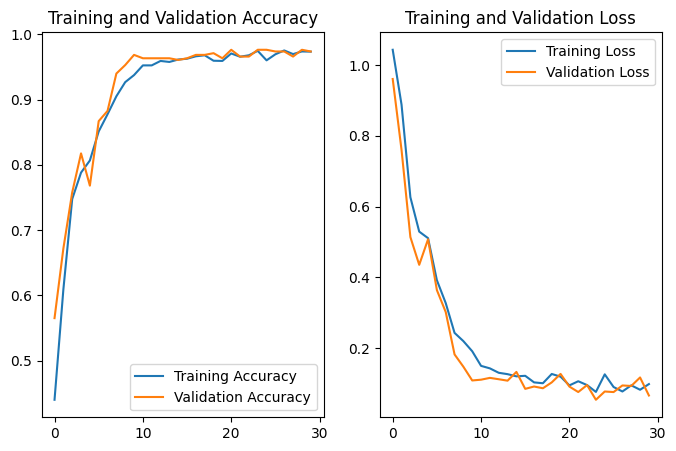

In [210]:
fig_trainVal_acc_c = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCH_30), acc_model_c, label='Training Accuracy')
plt.plot(range(EPOCH_30), val_acc_model_c, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH_30), loss_model_c, label='Training Loss')
plt.plot(range(EPOCH_30), val_loss_model_c, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
fig_trainVal_acc_c.savefig('train_val_acc_c.png', dpi=300)

#### b. Confusion Matrix

In [211]:
y_pred_model_c = []
y_true_model_c = []

# Loop through the test dataset to get true labels and predicted labels
for images, labels in test_ds_32:
    preds_model_c = model_cnn_c.predict(images)
    y_pred_model_c.extend(np.argmax(preds_model_c, axis=1))  # Get the index of the class with the highest probability
    y_true_model_c.extend(labels.numpy())  # Get the true labels

y_pred_model_c = np.array(y_pred_model_c)
y_true_model_c = np.array(y_true_model_c)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


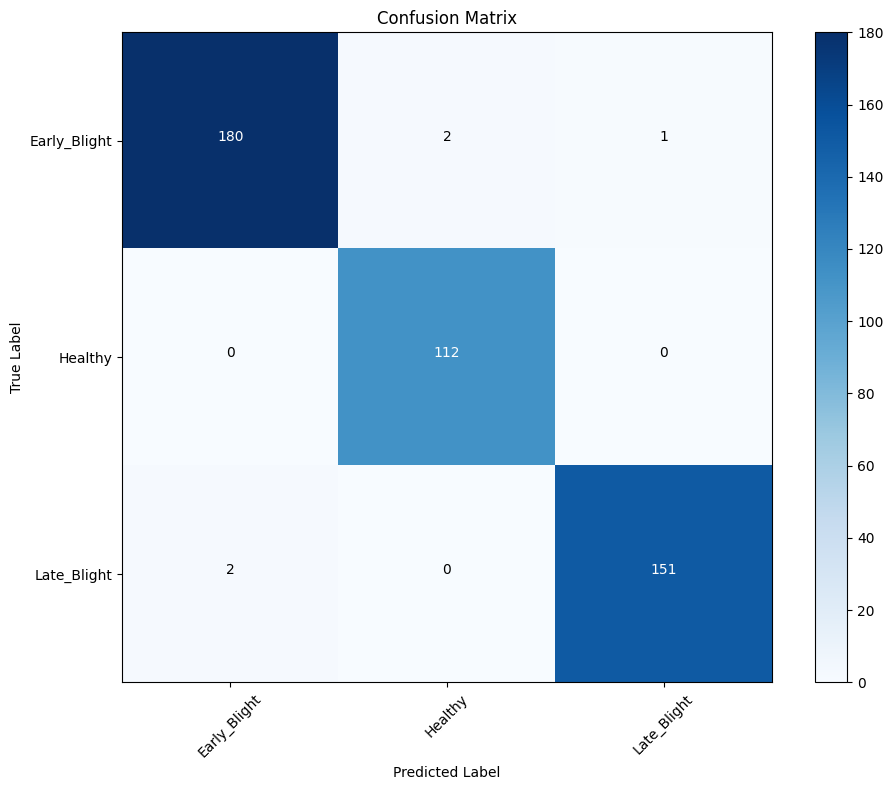

In [212]:
cm = confusion_matrix(y_true_model_c, y_pred_model_c)

def plot_confusion_matrix_model_c(cm, classes):
    fig_cm_c = plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Normalize the confusion matrix by rows (true labels)
    # cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fig_cm_c.savefig('cm_c.png', dpi=300)

plot_confusion_matrix_model_c(cm, class_names_32)
plt.show()

#### c. Precision, Recall, dan F1-Score

In [213]:
print(classification_report(y_true_model_c, y_pred_model_c, target_names=class_names_32))

              precision    recall  f1-score   support

Early_Blight       0.99      0.98      0.99       183
     Healthy       0.98      1.00      0.99       112
 Late_Blight       0.99      0.99      0.99       153

    accuracy                           0.99       448
   macro avg       0.99      0.99      0.99       448
weighted avg       0.99      0.99      0.99       448



### IV.2.4. Model D

**Optimizer Adam, epoch 50, jumlah conv layer 4, batch size 32**

#### a. Training-Validation Accuracy and Loss

In [214]:
history_d_4

In [215]:
history_d_4.params

{'verbose': 1, 'epochs': 50, 'steps': 101}

In [247]:
for i in range(-1, 0):  # Last epoch
    print(f"Epoch {i+len(history_d_4.history['loss'])+1}:")
    print(f"  training accuracy: {history_d_4.history['accuracy'][i]:.4f}")
    print(f"  training loss: {history_d_4.history['loss'][i]:.4f}")
    print(f"  val_accuracy: {history_d_4.history['val_accuracy'][i]:.4f}")
    print(f"  val_loss: {history_d_4.history['val_loss'][i]:.4f}")
    print()

Epoch 50:
  training accuracy: 0.9885
  training loss: 0.0353
  val_accuracy: 0.9896
  val_loss: 0.0409



In [248]:
acc_model_d_4 = history_d_4.history['accuracy']
val_acc_model_d_4 = history_d_4.history['val_accuracy']

loss_model_d_4 = history_d_4.history['loss']
val_loss_model_d_4 = history_d_4.history['val_loss']

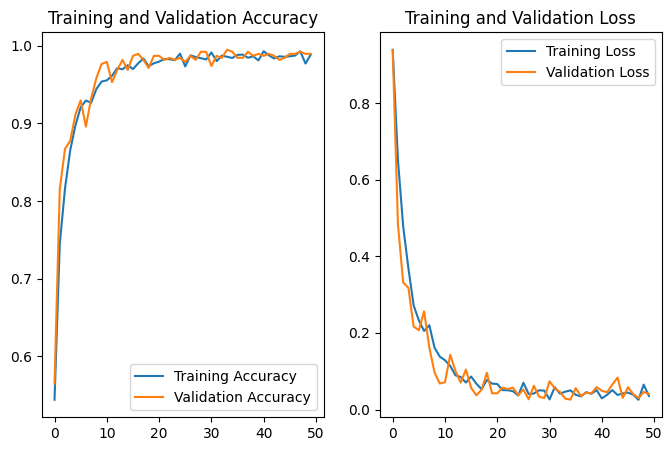

In [250]:
fig_trainVal_acc_d_ = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCH_50), acc_model_d_4, label='Training Accuracy')
plt.plot(range(EPOCH_50), val_acc_model_d_4, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH_50), loss_model_d_4, label='Training Loss')
plt.plot(range(EPOCH_50), val_loss_model_d_4, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
fig_trainVal_acc_d_.savefig('train_val_acc_d.png', dpi=300)

#### b. Confusion Matrix

In [251]:
y_pred_model_d_4 = []
y_true_model_d_4 = []

# Loop through the test dataset to get true labels and predicted labels
for images, labels in test_ds_32:
    preds_model_d_4 = model_cnn_d_4.predict(images)
    y_pred_model_d_4.extend(np.argmax(preds_model_d_4, axis=1))  # Get the index of the class with the highest probability
    y_true_model_d_4.extend(labels.numpy())  # Get the true labels

y_pred_model_d_4 = np.array(y_pred_model_d_4)
y_true_model_d_4 = np.array(y_true_model_d_4)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step


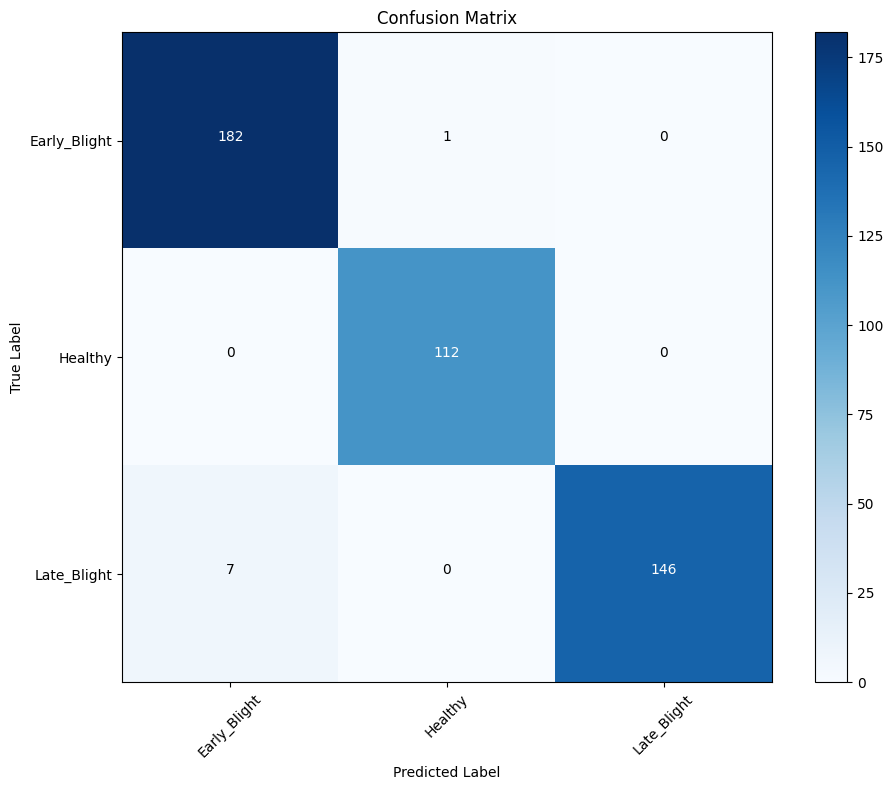

In [252]:
cm = confusion_matrix(y_true_model_d_4, y_pred_model_d_4)

def plot_confusion_matrix_model_d(cm, classes):
    fig_cm_d_4 = plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Normalize the confusion matrix by rows (true labels)
    # cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fig_cm_d_4.savefig('cm_d.png', dpi=300)

plot_confusion_matrix_model_d(cm, class_names_32)
plt.show()

#### c. Precision, Recall, dan F1-Score

In [253]:
print(classification_report(y_true_model_d_4, y_pred_model_d_4, target_names=class_names_32))

              precision    recall  f1-score   support

Early_Blight       0.96      0.99      0.98       183
     Healthy       0.99      1.00      1.00       112
 Late_Blight       1.00      0.95      0.98       153

    accuracy                           0.98       448
   macro avg       0.98      0.98      0.98       448
weighted avg       0.98      0.98      0.98       448



### IV.2.5. Model E

**Optimizer Adam, epoch 50, jumlah conv layer 6, batch size 32**

#### a. Training-Validation Accuracy and Loss

In [260]:
history_e

In [261]:
history_e.params

{'verbose': 1, 'epochs': 50, 'steps': 101}

In [262]:
for i in range(-1, 0):  # Last epoch
    print(f"Epoch {i+len(history_e.history['loss'])+1}:")
    print(f"  training accuracy: {history_e.history['accuracy'][i]:.4f}")
    print(f"  training loss: {history_e.history['loss'][i]:.4f}")
    print(f"  val_accuracy: {history_e.history['val_accuracy'][i]:.4f}")
    print(f"  val_loss: {history_e.history['val_loss'][i]:.4f}")
    print()

Epoch 50:
  training accuracy: 0.9913
  training loss: 0.0287
  val_accuracy: 0.9870
  val_loss: 0.0628



In [263]:
acc_model_e = history_e.history['accuracy']
val_acc_model_e = history_e.history['val_accuracy']

loss_model_e = history_e.history['loss']
val_loss_model_e = history_e.history['val_loss']

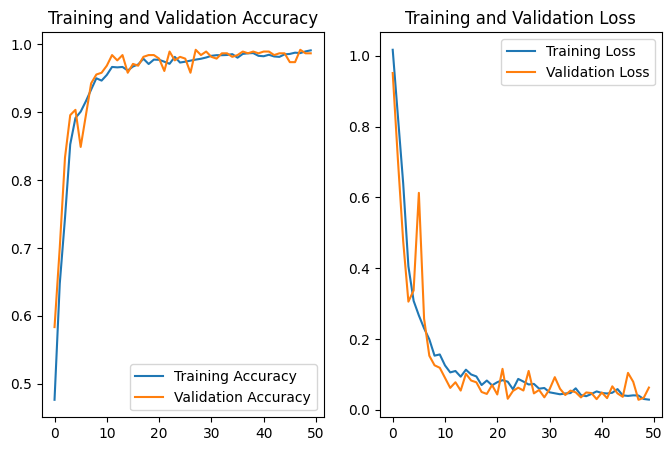

In [264]:
fig_trainVal_acc_e = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCH_50), acc_model_e, label='Training Accuracy')
plt.plot(range(EPOCH_50), val_acc_model_e, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH_50), loss_model_e, label='Training Loss')
plt.plot(range(EPOCH_50), val_loss_model_e, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
fig_trainVal_acc_e.savefig('train_val_acc_e.png', dpi=300)

#### b. Confusion Matrix

In [265]:
y_pred_model_e = []
y_true_model_e = []

# Loop through the test dataset to get true labels and predicted labels
for images, labels in test_ds_32:
    preds_model_e = model_cnn_e.predict(images)
    y_pred_model_e.extend(np.argmax(preds_model_e, axis=1))  # Get the index of the class with the highest probability
    y_true_model_e.extend(labels.numpy())  # Get the true labels

y_pred_model_e = np.array(y_pred_model_e)
y_true_model_e = np.array(y_true_model_e)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


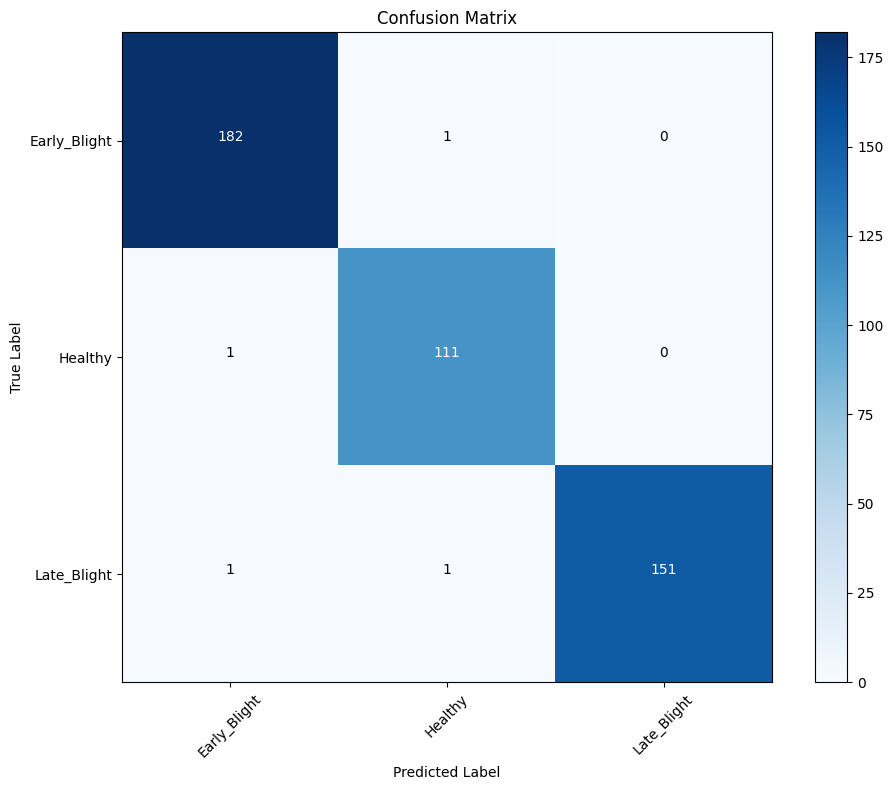

In [266]:
cm = confusion_matrix(y_true_model_e, y_pred_model_e)

def plot_confusion_matrix_model_e(cm, classes):
    fig_cm_e = plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Normalize the confusion matrix by rows (true labels)
    # cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fig_cm_e.savefig('cm_e.png', dpi=300)

plot_confusion_matrix_model_e(cm, class_names_32)
plt.show()

#### c. Precision, Recall, F1-Score

In [271]:
print(classification_report(y_true_model_e, y_pred_model_e, target_names=class_names_32))

              precision    recall  f1-score   support

Early_Blight       0.99      0.99      0.99       183
     Healthy       0.98      0.99      0.99       112
 Late_Blight       1.00      0.99      0.99       153

    accuracy                           0.99       448
   macro avg       0.99      0.99      0.99       448
weighted avg       0.99      0.99      0.99       448



### IV.2.6. Model F

**Optimizer Adam, epoch 50, jumlah conv layer 8, batch size 32**

#### a. Training-Validation Accuracy and Loss

In [268]:
history_f

In [269]:
history_d_4.params

{'verbose': 1, 'epochs': 50, 'steps': 101}

In [270]:
for i in range(-1, 0):  # Last epoch
    print(f"Epoch {i+len(history_f.history['loss'])+1}:")
    print(f"  training accuracy: {history_f.history['accuracy'][i]:.4f}")
    print(f"  training loss: {history_f.history['loss'][i]:.4f}")
    print(f"  val_accuracy: {history_f.history['val_accuracy'][i]:.4f}")
    print(f"  val_loss: {history_f.history['val_loss'][i]:.4f}")
    print()

Epoch 50:
  training accuracy: 0.9783
  training loss: 0.0771
  val_accuracy: 0.9583
  val_loss: 0.1299



In [273]:
acc_model_f = history_f.history['accuracy']
val_acc_model_f = history_f.history['val_accuracy']

loss_model_f = history_f.history['loss']
val_loss_model_f = history_f.history['val_loss']

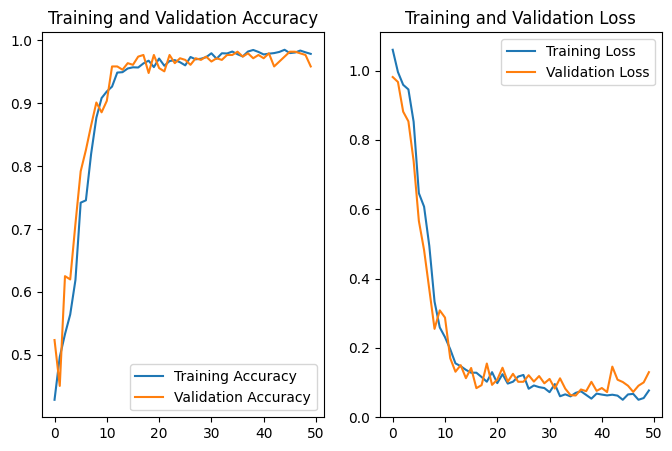

In [275]:
fig_trainVal_acc_f = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCH_50), acc_model_f, label='Training Accuracy')
plt.plot(range(EPOCH_50), val_acc_model_f, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH_50), loss_model_f, label='Training Loss')
plt.plot(range(EPOCH_50), val_loss_model_f, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
fig_trainVal_acc_f.savefig('train_val_acc_f.png', dpi=300)

#### b. Confusion Matrix

In [276]:
y_pred_model_f = []
y_true_model_f = []

# Loop through the test dataset to get true labels and predicted labels
for images, labels in test_ds_32:
    preds_model_f = model_cnn_f.predict(images)
    y_pred_model_f.extend(np.argmax(preds_model_f, axis=1))  # Get the index of the class with the highest probability
    y_true_model_f.extend(labels.numpy())  # Get the true labels

y_pred_model_f = np.array(y_pred_model_f)
y_true_model_f = np.array(y_true_model_f)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 553ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step


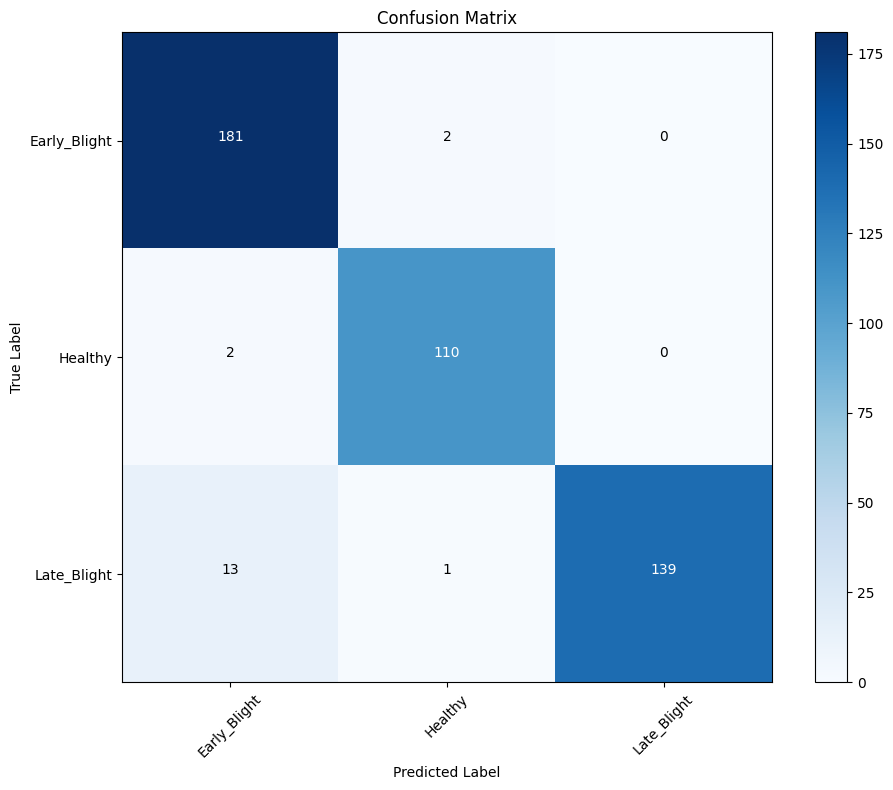

In [277]:
cm = confusion_matrix(y_true_model_f, y_pred_model_f)

def plot_confusion_matrix_model_f(cm, classes):
    fig_cm_f = plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Normalize the confusion matrix by rows (true labels)
    # cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fig_cm_f.savefig('cm_f.png', dpi=300)

plot_confusion_matrix_model_f(cm, class_names_32)
plt.show()

#### c. Precision, Recall, dan F1-Score

In [278]:
print(classification_report(y_true_model_f, y_pred_model_f, target_names=class_names_32))

              precision    recall  f1-score   support

Early_Blight       0.92      0.99      0.96       183
     Healthy       0.97      0.98      0.98       112
 Late_Blight       1.00      0.91      0.95       153

    accuracy                           0.96       448
   macro avg       0.97      0.96      0.96       448
weighted avg       0.96      0.96      0.96       448



### IV.2.7. Model G

**Optimizer RMSProp, epoch 30, jumlah conv layer 4, batch size 32**

#### a. Training-Validation Accuracy and Loss

In [287]:
history_g

In [281]:
for i in range(-1, 0):  # Last epoch
    print(f"Epoch {i+len(history_g.history['loss'])+1}:")
    print(f"  training accuracy: {history_g.history['accuracy'][i]:.4f}")
    print(f"  training loss: {history_g.history['loss'][i]:.4f}")
    print(f"  val_accuracy: {history_g.history['val_accuracy'][i]:.4f}")
    print(f"  val_loss: {history_g.history['val_loss'][i]:.4f}")
    print()

Epoch 30:
  training accuracy: 0.9718
  training loss: 0.0886
  val_accuracy: 0.9688
  val_loss: 0.0785



In [282]:
acc_model_g = history_g.history['accuracy']
val_acc_model_g = history_g.history['val_accuracy']

loss_model_g = history_g.history['loss']
val_loss_model_g = history_g.history['val_loss']

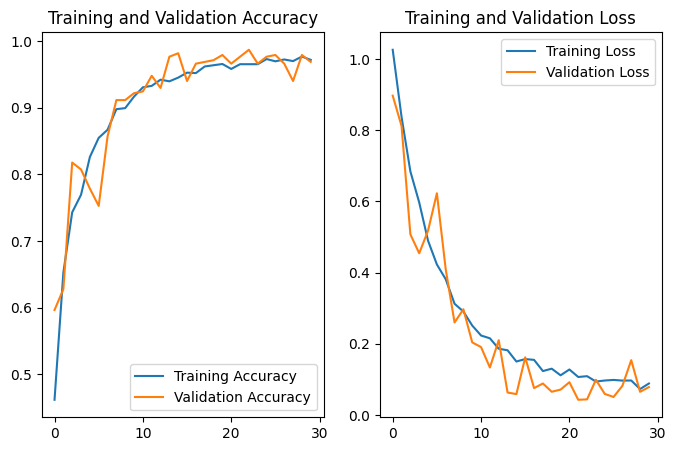

In [283]:
fig_trainVal_acc_g = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCH_30), acc_model_g, label='Training Accuracy')
plt.plot(range(EPOCH_30), val_acc_model_g, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH_30), loss_model_g, label='Training Loss')
plt.plot(range(EPOCH_30), val_loss_model_g, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
fig_trainVal_acc_g.savefig('train_val_acc_g.png', dpi=300)

#### b. Confusion Matrix

In [284]:
y_pred_model_g = []
y_true_model_g = []

# Loop through the test dataset to get true labels and predicted labels
for images, labels in test_ds_32:
    preds_model_g = model_cnn_g.predict(images)
    y_pred_model_g.extend(np.argmax(preds_model_g, axis=1))  # Get the index of the class with the highest probability
    y_true_model_g.extend(labels.numpy())  # Get the true labels

y_pred_model_g = np.array(y_pred_model_g)
y_true_model_g = np.array(y_true_model_g)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step


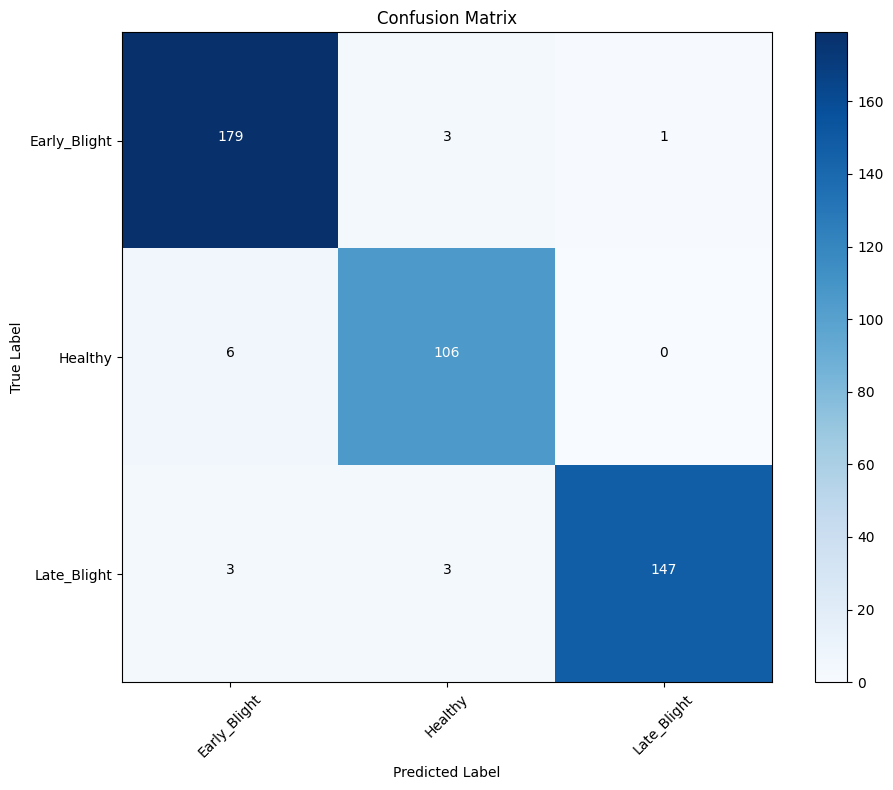

In [285]:
cm = confusion_matrix(y_true_model_g, y_pred_model_g)

def plot_confusion_matrix_model_g(cm, classes):
    fig_cm_g = plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Normalize the confusion matrix by rows (true labels)
    # cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fig_cm_g.savefig('cm_g.png', dpi=300)

plot_confusion_matrix_model_g(cm, class_names_32)
plt.show()

#### c. Precision, Recall, dan F1-Score

In [286]:
print(classification_report(y_true_model_g, y_pred_model_g, target_names=class_names_32))

              precision    recall  f1-score   support

Early_Blight       0.95      0.98      0.96       183
     Healthy       0.95      0.95      0.95       112
 Late_Blight       0.99      0.96      0.98       153

    accuracy                           0.96       448
   macro avg       0.96      0.96      0.96       448
weighted avg       0.96      0.96      0.96       448



### IV.2.8. Model H

**Optimizer RMSProp, epoch 30, jumlah conv layer 6, batch size 32**

#### a. Training-Validation Accuracy and Loss

In [290]:
history_h_2

In [291]:
for i in range(-1, 0):  # Last epoch
    print(f"Epoch {i+len(history_h_2.history['loss'])+1}:")
    print(f"  training accuracy: {history_h_2.history['accuracy'][i]:.4f}")
    print(f"  training loss: {history_h_2.history['loss'][i]:.4f}")
    print(f"  val_accuracy: {history_h_2.history['val_accuracy'][i]:.4f}")
    print(f"  val_loss: {history_h_2.history['val_loss'][i]:.4f}")
    print()

Epoch 30:
  training accuracy: 0.9759
  training loss: 0.0829
  val_accuracy: 0.9453
  val_loss: 0.1689



In [293]:
acc_model_h_2 = history_h_2.history['accuracy']
val_acc_model_h_2 = history_h_2.history['val_accuracy']

loss_model_h_2 = history_h_2.history['loss']
val_loss_model_h_2 = history_h_2.history['val_loss']

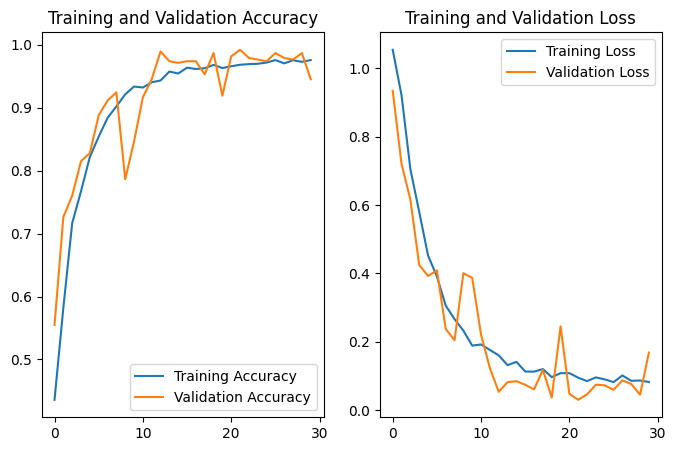

In [294]:
fig_trainVal_acc_h_2 = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCH_30), acc_model_h_2, label='Training Accuracy')
plt.plot(range(EPOCH_30), val_acc_model_h_2, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH_30), loss_model_h_2, label='Training Loss')
plt.plot(range(EPOCH_30), val_loss_model_h_2, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
fig_trainVal_acc_h_2.savefig('train_val_acc_h.png', dpi=300)

#### b. Confusion Matrix

In [295]:
y_pred_model_h_2 = []
y_true_model_h_2 = []

# Loop through the test dataset to get true labels and predicted labels
for images, labels in test_ds_32:
    preds_model_h_2 = model_cnn_h_2.predict(images)
    y_pred_model_h_2.extend(np.argmax(preds_model_h_2, axis=1))  # Get the index of the class with the highest probability
    y_true_model_h_2.extend(labels.numpy())  # Get the true labels

y_pred_model_h_2 = np.array(y_pred_model_h_2)
y_true_model_h_2 = np.array(y_true_model_h_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step


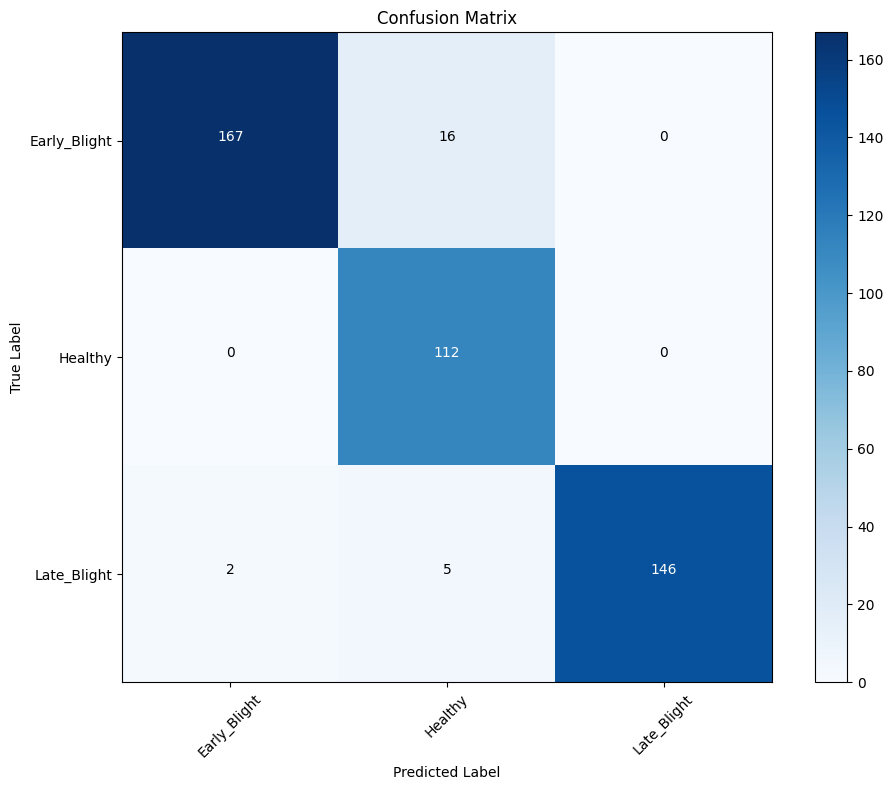

In [296]:
cm = confusion_matrix(y_true_model_h_2, y_pred_model_h_2)

def plot_confusion_matrix_model_h(cm, classes):
    fig_cm_h = plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Normalize the confusion matrix by rows (true labels)
    # cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fig_cm_h.savefig('cm_h.png', dpi=300)

plot_confusion_matrix_model_h(cm, class_names_32)
plt.show()

#### c. Precision, Recall, dan F1-Score

In [297]:
print(classification_report(y_true_model_h_2, y_pred_model_h_2, target_names=class_names_32))

              precision    recall  f1-score   support

Early_Blight       0.99      0.91      0.95       183
     Healthy       0.84      1.00      0.91       112
 Late_Blight       1.00      0.95      0.98       153

    accuracy                           0.95       448
   macro avg       0.94      0.96      0.95       448
weighted avg       0.96      0.95      0.95       448



### IV.2.9. Model I

**Optimizer RMSProp, epoch 30, jumlah conv layer 8, batch size 32**

#### a. Training-Validation Accuracy and Loss

In [298]:
history_i

In [299]:
for i in range(-1, 0):  # Last epoch
    print(f"Epoch {i+len(history_i.history['loss'])+1}:")
    print(f"  training accuracy: {history_i.history['accuracy'][i]:.4f}")
    print(f"  training loss: {history_i.history['loss'][i]:.4f}")
    print(f"  val_accuracy: {history_i.history['val_accuracy'][i]:.4f}")
    print(f"  val_loss: {history_i.history['val_loss'][i]:.4f}")
    print()

Epoch 30:
  training accuracy: 0.9697
  training loss: 0.1104
  val_accuracy: 0.9609
  val_loss: 0.1523



In [300]:
acc_model_i = history_i.history['accuracy']
val_acc_model_i = history_i.history['val_accuracy']

loss_model_i = history_i.history['loss']
val_loss_model_i = history_i.history['val_loss']

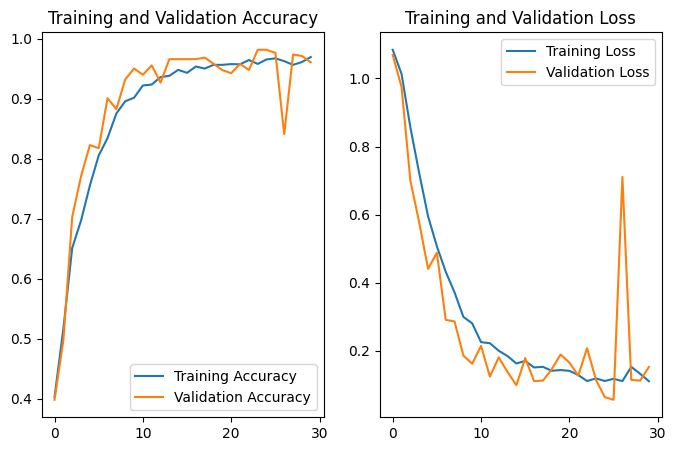

In [301]:
fig_trainVal_acc_i = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCH_30), acc_model_i, label='Training Accuracy')
plt.plot(range(EPOCH_30), val_acc_model_i, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH_30), loss_model_i, label='Training Loss')
plt.plot(range(EPOCH_30), val_loss_model_i, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
fig_trainVal_acc_i.savefig('train_val_acc_i.png', dpi=300)

#### b. Confusion Matrix

In [326]:
y_pred_model_i = []
y_true_model_i = []

# Loop through the test dataset to get true labels and predicted labels
for images, labels in test_ds_32:
    preds_model_i = model_cnn_i.predict(images)
    y_pred_model_i.extend(np.argmax(preds_model_i, axis=1))  # Get the index of the class with the highest probability
    y_true_model_i.extend(labels.numpy())  # Get the true labels

y_pred_model_i = np.array(y_pred_model_i)
y_true_model_i = np.array(y_true_model_i)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step


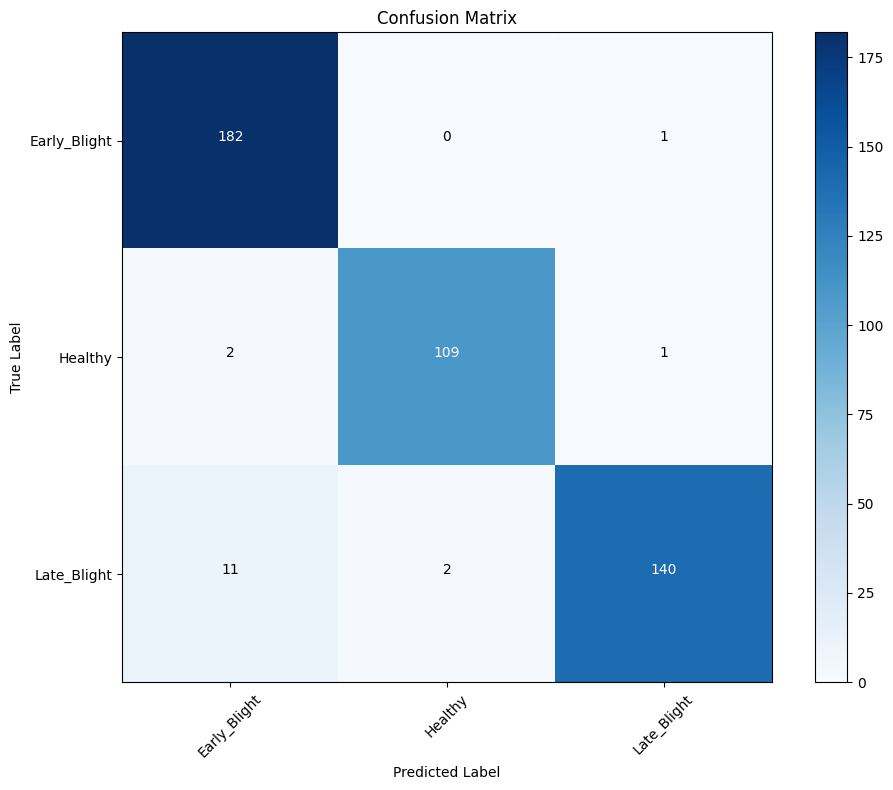

In [327]:
cm = confusion_matrix(y_true_model_i, y_pred_model_i)

def plot_confusion_matrix_model_i(cm, classes):
    fig_cm_i = plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Normalize the confusion matrix by rows (true labels)
    # cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fig_cm_i.savefig('cm_i.png', dpi=300)

plot_confusion_matrix_model_i(cm, class_names_32)
plt.show()

#### c. Precision, Recall, dan F1-Score

In [328]:
print(classification_report(y_true_model_i, y_pred_model_i, target_names=class_names_32))

              precision    recall  f1-score   support

Early_Blight       0.93      0.99      0.96       183
     Healthy       0.98      0.97      0.98       112
 Late_Blight       0.99      0.92      0.95       153

    accuracy                           0.96       448
   macro avg       0.97      0.96      0.96       448
weighted avg       0.96      0.96      0.96       448



### IV.2.10. Model J

**Optimizer RMSProp, epoch 50, jumlah conv layer 4, batch size 32**

#### a. Training-Validation Accuracy and Loss

In [303]:
history_j

In [304]:
for i in range(-1, 0):  # Last epoch
    print(f"Epoch {i+len(history_j.history['loss'])+1}:")
    print(f"  training accuracy: {history_j.history['accuracy'][i]:.4f}")
    print(f"  training loss: {history_j.history['loss'][i]:.4f}")
    print(f"  val_accuracy: {history_j.history['val_accuracy'][i]:.4f}")
    print(f"  val_loss: {history_g.history['val_loss'][i]:.4f}")
    print()

Epoch 50:
  training accuracy: 0.9808
  training loss: 0.0742
  val_accuracy: 0.9948
  val_loss: 0.0785



In [305]:
acc_model_j = history_j.history['accuracy']
val_acc_model_j = history_j.history['val_accuracy']

loss_model_j = history_j.history['loss']
val_loss_model_j = history_j.history['val_loss']

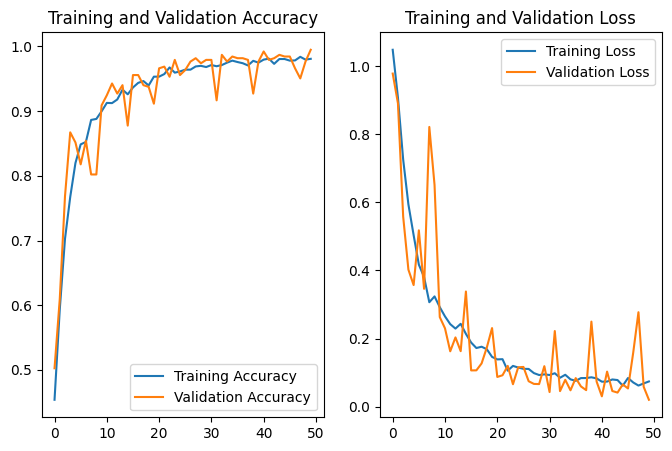

In [306]:
fig_trainVal_acc_j = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCH_50), acc_model_j, label='Training Accuracy')
plt.plot(range(EPOCH_50), val_acc_model_j, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH_50), loss_model_j, label='Training Loss')
plt.plot(range(EPOCH_50), val_loss_model_j, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
fig_trainVal_acc_j.savefig('train_val_acc_j.png', dpi=300)

#### b. Confusion Matrix

In [307]:
y_pred_model_j = []
y_true_model_j = []

# Loop through the test dataset to get true labels and predicted labels
for images, labels in test_ds_32:
    preds_model_j = model_cnn_j.predict(images)
    y_pred_model_j.extend(np.argmax(preds_model_j, axis=1))  # Get the index of the class with the highest probability
    y_true_model_j.extend(labels.numpy())  # Get the true labels

y_pred_model_j = np.array(y_pred_model_j)
y_true_model_j = np.array(y_true_model_j)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


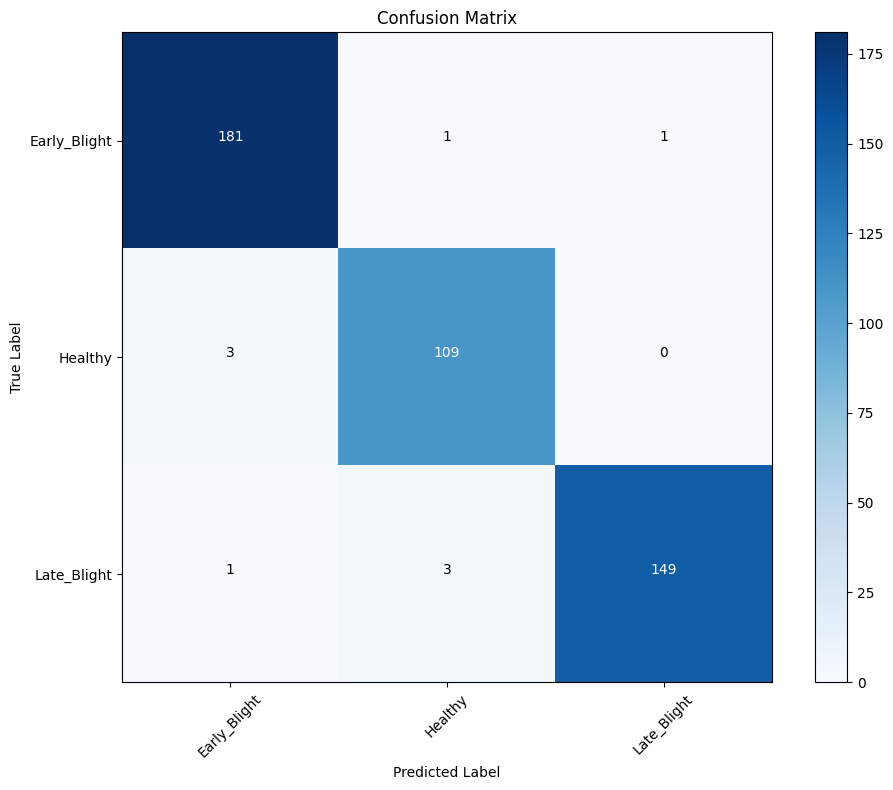

In [308]:
cm = confusion_matrix(y_true_model_j, y_pred_model_j)

def plot_confusion_matrix_model_j(cm, classes):
    fig_cm_j = plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Normalize the confusion matrix by rows (true labels)
    # cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fig_cm_j.savefig('cm_j.png', dpi=300)

plot_confusion_matrix_model_j(cm, class_names_32)
plt.show()

#### c. Precision, Recall, dan F1-Score

In [309]:
print(classification_report(y_true_model_j, y_pred_model_j, target_names=class_names_32))

              precision    recall  f1-score   support

Early_Blight       0.98      0.99      0.98       183
     Healthy       0.96      0.97      0.97       112
 Late_Blight       0.99      0.97      0.98       153

    accuracy                           0.98       448
   macro avg       0.98      0.98      0.98       448
weighted avg       0.98      0.98      0.98       448



### IV.2.11. Model k

**Optimizer RMSProp, epoch 50, jumlah conv layer 6, batch size 32**

#### a. Training-Validation Accuracy and Loss

In [310]:
history_k

In [311]:
for i in range(-1, 0):  # Last epoch
    print(f"Epoch {i+len(history_k.history['loss'])+1}:")
    print(f"  training accuracy: {history_k.history['accuracy'][i]:.4f}")
    print(f"  training loss: {history_k.history['loss'][i]:.4f}")
    print(f"  val_accuracy: {history_k.history['val_accuracy'][i]:.4f}")
    print(f"  val_loss: {history_k.history['val_loss'][i]:.4f}")
    print()

Epoch 50:
  training accuracy: 0.9833
  training loss: 0.0698
  val_accuracy: 0.9844
  val_loss: 0.0556



In [312]:
acc_model_k = history_k.history['accuracy']
val_acc_model_k = history_k.history['val_accuracy']

loss_model_k = history_k.history['loss']
val_loss_model_k = history_k.history['val_loss']

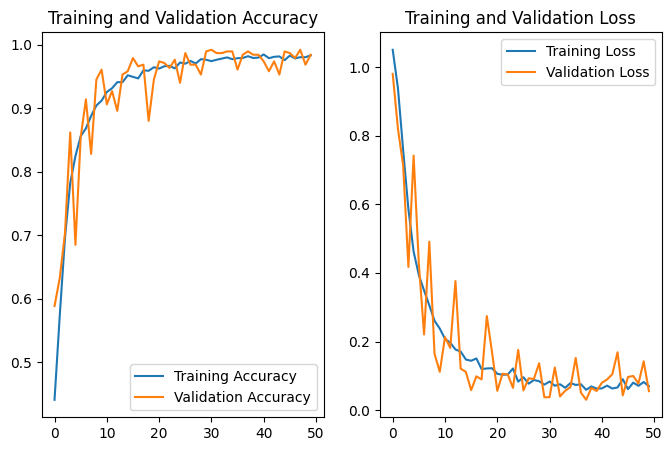

In [313]:
fig_trainVal_acc_k = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCH_50), acc_model_k, label='Training Accuracy')
plt.plot(range(EPOCH_50), val_acc_model_k, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH_50), loss_model_k, label='Training Loss')
plt.plot(range(EPOCH_50), val_loss_model_k, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
fig_trainVal_acc_k.savefig('train_val_acc_k.png', dpi=300)

#### b. Confusion Matrix

In [314]:
y_pred_model_k = []
y_true_model_k = []

# Loop through the test dataset to get true labels and predicted labels
for images, labels in test_ds_32:
    preds_model_k = model_cnn_k.predict(images)
    y_pred_model_k.extend(np.argmax(preds_model_k, axis=1))  # Get the index of the class with the highest probability
    y_true_model_k.extend(labels.numpy())  # Get the true labels

y_pred_model_k = np.array(y_pred_model_k)
y_true_model_k = np.array(y_true_model_k)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step


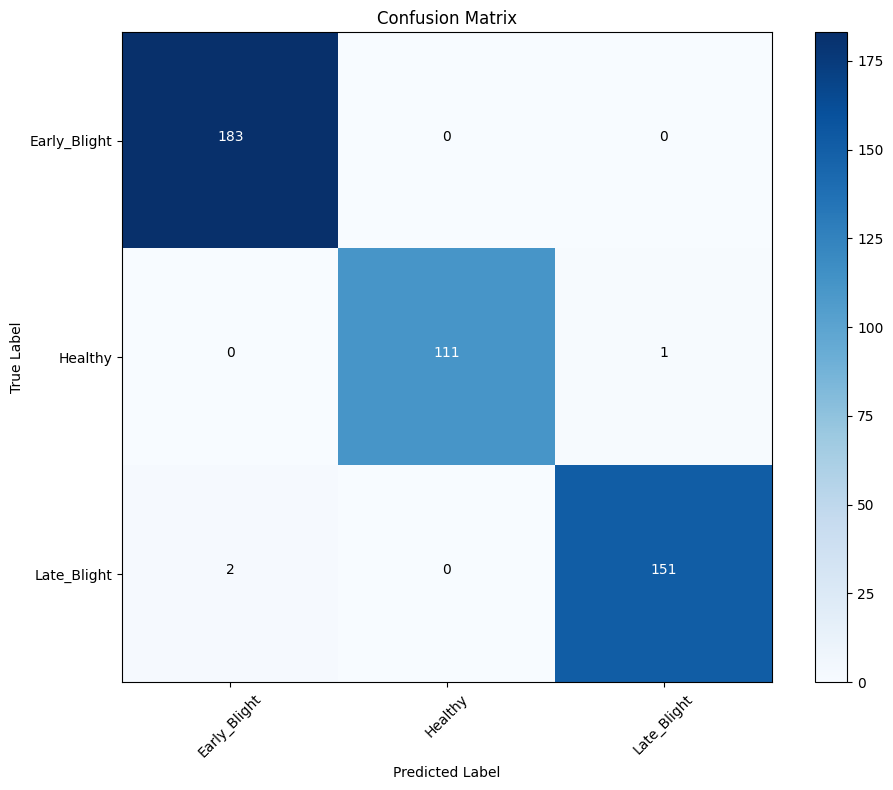

In [315]:
cm = confusion_matrix(y_true_model_k, y_pred_model_k)

def plot_confusion_matrix_model_k(cm, classes):
    fig_cm_k = plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Normalize the confusion matrix by rows (true labels)
    # cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fig_cm_k.savefig('cm_k.png', dpi=300)

plot_confusion_matrix_model_k(cm, class_names_32)
plt.show()

#### c. Precision, Recall, dan F1-Score

In [316]:
print(classification_report(y_true_model_k, y_pred_model_k, target_names=class_names_32))

              precision    recall  f1-score   support

Early_Blight       0.99      1.00      0.99       183
     Healthy       1.00      0.99      1.00       112
 Late_Blight       0.99      0.99      0.99       153

    accuracy                           0.99       448
   macro avg       0.99      0.99      0.99       448
weighted avg       0.99      0.99      0.99       448



### IV.2.12. Model L

**Optimizer RMSProp, epoch 50, jumlah conv layer 8, batch size 32**

#### a. Training-Validation Accuracy and Loss

In [318]:
history_l_2

In [319]:
for i in range(-1, 0):  # Last epoch
    print(f"Epoch {i+len(history_l_2.history['loss'])+1}:")
    print(f"  training accuracy: {history_l_2.history['accuracy'][i]:.4f}")
    print(f"  training loss: {history_l_2.history['loss'][i]:.4f}")
    print(f"  val_accuracy: {history_l_2.history['val_accuracy'][i]:.4f}")
    print(f"  val_loss: {history_l_2.history['val_loss'][i]:.4f}")
    print()

Epoch 50:
  training accuracy: 0.9765
  training loss: 0.0824
  val_accuracy: 0.9661
  val_loss: 0.1766



In [320]:
acc_model_l_2 = history_l_2.history['accuracy']
val_acc_model_l_2 = history_l_2.history['val_accuracy']

loss_model_l_2 = history_l_2.history['loss']
val_loss_model_l_2 = history_l_2.history['val_loss']

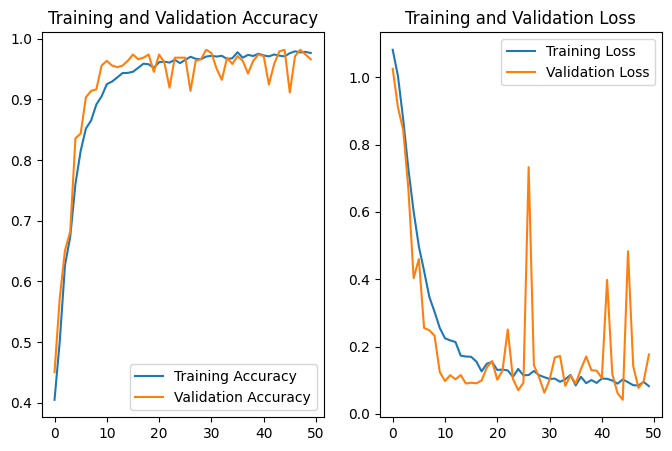

In [322]:
fig_trainVal_acc_l_2 = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCH_50), acc_model_l_2, label='Training Accuracy')
plt.plot(range(EPOCH_50), val_acc_model_l_2, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCH_50), loss_model_l_2, label='Training Loss')
plt.plot(range(EPOCH_50), val_loss_model_l_2, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
fig_trainVal_acc_l_2.savefig('train_val_acc_l.png', dpi=300)

#### b. Confusion Matrix

In [323]:
y_pred_model_l_2 = []
y_true_model_l_2 = []

# Loop through the test dataset to get true labels and predicted labels
for images, labels in test_ds_32:
    preds_model_l_2 = model_cnn_l_2.predict(images)
    y_pred_model_l_2.extend(np.argmax(preds_model_l_2, axis=1))  # Get the index of the class with the highest probability
    y_true_model_l_2.extend(labels.numpy())  # Get the true labels

y_pred_model_l_2 = np.array(y_pred_model_l_2)
y_true_model_l_2 = np.array(y_true_model_l_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step


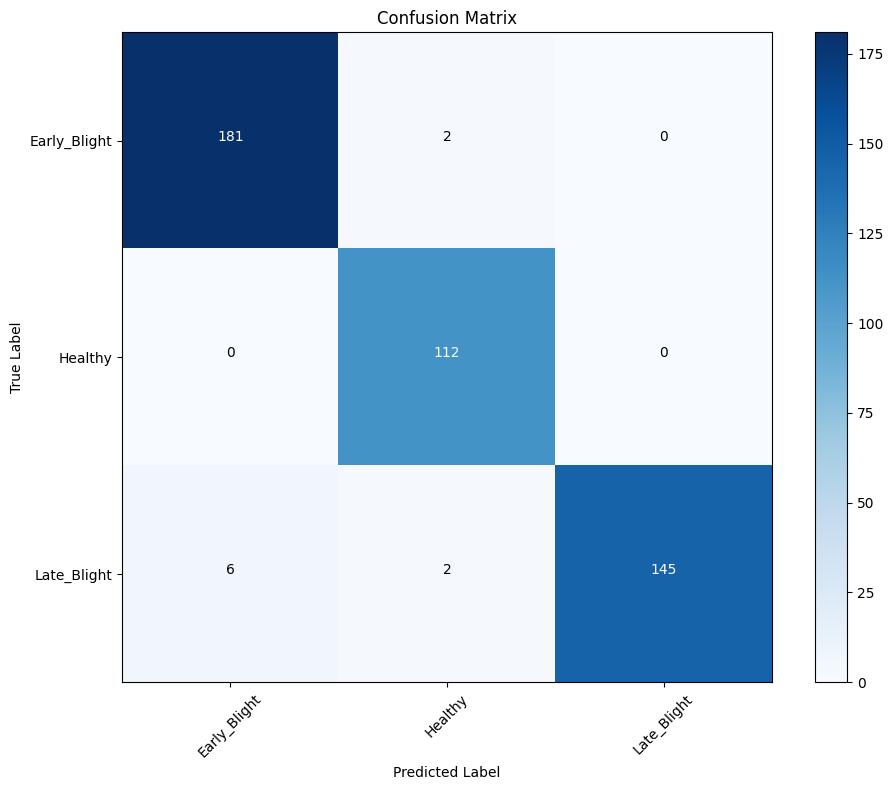

In [324]:
cm = confusion_matrix(y_true_model_l_2, y_pred_model_l_2)

def plot_confusion_matrix_model_l_2(cm, classes):
    fig_cm_l_2 = plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Normalize the confusion matrix by rows (true labels)
    # cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fig_cm_l_2.savefig('cm_l.png', dpi=300)

plot_confusion_matrix_model_l_2(cm, class_names_32)
plt.show()

#### c. Precision, Recall, dan F1-Score

In [325]:
print(classification_report(y_true_model_l_2, y_pred_model_l_2, target_names=class_names_32))

              precision    recall  f1-score   support

Early_Blight       0.97      0.99      0.98       183
     Healthy       0.97      1.00      0.98       112
 Late_Blight       1.00      0.95      0.97       153

    accuracy                           0.98       448
   macro avg       0.98      0.98      0.98       448
weighted avg       0.98      0.98      0.98       448



### IV.3. Hasil Model Creation Tahap I

Berdasarkan evaluasi pada model creation tahap I, peneliti memperhatikan bahwa model K lebih unggul. Model E memiliki hasil yang beda tipis dengan model K. Namun karena mempertimbangkan stabilitas accuracy-loss pada saat pelatihan, model K sangat fluktuaktif dikarenakan sifat dari optimizer RMSProp, dan model E lebih stabil dikarenakan sifat optimizer Adam.

**Maka peneliti akan memilih model E sebagai model terbaik pada tahap satu ini (Optimizer: Adam Epoch: 50 Jumlah Conv Layer: 6 Batch Size 32) untuk dilanjut pada model creation tahap II, dengan melakukan modifikasi pada batch size**